In [11]:
import requests
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import json
import geopandas as gpd
import matplotlib.pyplot as plt
from io import BytesIO
import os
import time
from shapely.geometry import Point
import cdsapi


In [12]:


class CaribooDataFetcher:
    def __init__(self, official_zones_gdf=None):
        self.zones_gdf = official_zones_gdf
        self.cds_client = cdsapi.Client(timeout=600)


    def _generate_valid_grid_points(self, polygon, resolution=0.1):
        """
        Generates a grid of lat/lon points and keeps only those INSIDE the polygon.
        resolution: Step size in degrees (0.1 deg ~= 11km)
        """
        # ---------------------------------------------------------
        # CRITICAL FIX: Unit Alignment
        # 1. Convert the single polygon to WGS84 (Lat/Lon) to get bounds in Degrees
        # ---------------------------------------------------------
        poly_geo = gpd.GeoSeries([polygon], crs=self.zones_gdf.crs)
        poly_wgs84 = poly_geo.to_crs("EPSG:4326").iloc[0]
        
        minx, miny, maxx, maxy = poly_wgs84.bounds
        
        # 2. Generate Grid (Now using correct Degree units)
        lats = np.arange(miny, maxy, resolution)
        lons = np.arange(minx, maxx, resolution)
        grid_points = []
        
        for lat in lats:
            for lon in lons:
                grid_points.append(Point(lon, lat))
        
        if not grid_points:
            print("   ! Warning: Grid generation produced 0 points. Check resolution.")
            return []

        # 3. Filter Points (The Cookie Cutter)
        # We create the grid in WGS84...
        grid_gdf = gpd.GeoDataFrame(geometry=grid_points, crs="EPSG:4326")
        
        # ...but we project it to BC Albers (Meters) to match the official polygon 
        # for the most accurate inclusion test (Spatial Join)
        grid_gdf_proj = grid_gdf.to_crs(self.zones_gdf.crs)
        poly_gdf_proj = gpd.GeoDataFrame(geometry=[polygon], crs=self.zones_gdf.crs)
        
        valid_points_gdf = gpd.sjoin(grid_gdf_proj, poly_gdf_proj, how="inner", predicate="within")
        
        # 4. Convert valid points back to Lat/Lon for the API
        valid_points_gdf = valid_points_gdf.to_crs("EPSG:4326")
        
        print(f"   > Grid Generation: Created {len(grid_points)} candidates -> Kept {len(valid_points_gdf)} valid points inside zone.")
        return list(zip(valid_points_gdf.geometry.y, valid_points_gdf.geometry.x))
    
    
    def fetch_regional_weather_era5(self, zone_name, start_date, end_date, resolution=0.1):
        """
        Fetches weather using ERA5 daily statistics dataset (new method as of 2024+).
        This uses pre-calculated daily aggregates, eliminating the need for hourly processing.
        
        Parameters:
        - zone_name: Fire zone name
        - start_date: Format 'YYYY-MM-DD'
        - end_date: Format 'YYYY-MM-DD'
        - resolution: Grid resolution in degrees
        """
        if self.zones_gdf is None:
            raise ValueError("Official Fire Zones GeoDataFrame not loaded.")

        target_zone = self.zones_gdf[self.zones_gdf['MOF_FIRE_ZONE_NAME'] == zone_name]
        if target_zone.empty:
            raise ValueError(f"Zone '{zone_name}' not found.")
        
        polygon = target_zone.geometry.iloc[0]
        
        # Get bounding box for the zone
        poly_wgs84 = gpd.GeoSeries([polygon], crs=self.zones_gdf.crs).to_crs("EPSG:4326").iloc[0]
        minx, miny, maxx, maxy = poly_wgs84.bounds
        
        # Add small buffer to ensure coverage
        buffer = 0.25  # degrees
        area = [maxy + buffer, minx - buffer, miny - buffer, maxx + buffer]  # North, West, South, East

        print(f"\nFetching ERA5 daily statistics for {zone_name}...")
        print(f"   Date Range: {start_date} to {end_date}")
        print(f"   Spatial Area: [{miny:.2f}°N to {maxy:.2f}°N, {minx:.2f}°W to {maxx:.2f}°W]")
        
        # Parse dates
        start_year = int(start_date.split('-')[0])
        end_year = int(end_date.split('-')[0])
        start_month = int(start_date.split('-')[1])
        end_month = int(end_date.split('-')[1])
        
        all_files = []
        
        # Generate year-month combinations
        for year in range(start_year, end_year + 1):
            for month in range(1, 13):
                # Skip months outside the date range
                if (year == start_year and month < start_month):
                    continue
                if (year == end_year and month > end_month):
                    continue
                
                month_str = f"{month:02d}"
                print(f"   > Requesting {year}-{month_str}...", end=" ", flush=True)
                
                # Output filename
                filename = f"era5_daily_{zone_name}_{year}_{month_str}.zip"
                
                try:
                    # Use the new daily statistics dataset
                    self.cds_client.retrieve(
                        'derived-era5-single-levels-daily-statistics',
                        {
                            'product_type': 'reanalysis',
                            'variable': [
                                '2m_temperature',
                                '2m_dewpoint_temperature',
                                'total_precipitation',
                                '10m_u_component_of_wind',
                                '10m_v_component_of_wind',
                            ],
                            'year': str(year),
                            'month': month_str,
                            'day': [f"{d:02d}" for d in range(1, 32)],
                            'daily_statistic': 'daily_mean',  # Options: daily_mean, daily_maximum, daily_minimum, daily_sum
                            'time_zone': 'utc+00:00',
                            'frequency': '1_hourly',
                            'area': area,
                            'data_format': 'netcdf',
                            'download_format': 'unarchived',
                        },
                        filename.replace('.zip', '.nc')
                    )
                    
                    all_files.append(filename.replace('.zip', '.nc'))
                    print("✓")
                    time.sleep(2)  # Polite delay
                    
                except Exception as e:
                    print(f"✗ Error: {e}")
                    continue
        
        if not all_files:
            print("✗ No data retrieved.")
            return None
        
        # Process NetCDF files
        print("\n   > Processing NetCDF files...")
        all_daily_data = []
        
        for nc_file in all_files:
            try:
                ds = xr.open_dataset(nc_file)
                
                # Calculate wind speed from components
                ds['wind_speed_10m'] = np.sqrt(ds['u10']**2 + ds['v10']**2)
                
                # Convert temperature from Kelvin to Celsius
                ds['temp_celsius'] = ds['t2m'] - 273.15
                ds['dewpoint_celsius'] = ds['d2m'] - 273.15
                
                # Convert precipitation from meters to mm
                # Note: For total_precipitation with daily_mean, multiply by 24 to get daily total
                ds['precip_mm'] = ds['tp'] * 1000
                
                # Calculate relative humidity using Magnus formula
                # RH = 100 * (EXP((17.625*TD)/(243.04+TD))/EXP((17.625*T)/(243.04+T)))
                es_t = np.exp((17.625 * ds['temp_celsius']) / (243.04 + ds['temp_celsius']))
                es_td = np.exp((17.625 * ds['dewpoint_celsius']) / (243.04 + ds['dewpoint_celsius']))
                ds['relative_humidity'] = 100 * (es_td / es_t)
                
                # Spatially average over the zone (regional mean)
                spatial_mean = ds.mean(dim=['longitude', 'latitude'])
                
                # Convert to DataFrame
                df = spatial_mean.to_dataframe().reset_index()
                all_daily_data.append(df)
                
                # Clean up
                ds.close()
                
            except Exception as e:
                print(f"   ! Error processing {nc_file}: {e}")
                continue
        
        if not all_daily_data:
            print("✗ No data processed.")
            return None
        
        # Combine all months
        full_df = pd.concat(all_daily_data, ignore_index=True)
        
        # Select and rename columns to match your original format
        regional_weather = full_df[[
            'time', 'temp_celsius', 'precip_mm', 
            'wind_speed_10m', 'relative_humidity', 'dewpoint_celsius'
        ]].copy()
        
        regional_weather.columns = [
            'Date', 'temperature_2m_mean', 'precipitation_sum',
            'wind_speed_10m_max', 'relative_humidity_2m_mean', 'dew_point_2m_mean'
        ]
        
        # Filter to exact date range
        regional_weather['Date'] = pd.to_datetime(regional_weather['Date'])
        regional_weather = regional_weather[
            (regional_weather['Date'] >= start_date) & 
            (regional_weather['Date'] <= end_date)
        ]
        
        regional_weather = regional_weather.sort_values('Date').reset_index(drop=True)
        
        print(f"✓ Success: Retrieved {len(regional_weather)} days of data for {zone_name}")
        return regional_weather

       

In [13]:
# 1. Load the Official Shapefile first
import geopandas as gpd
from io import BytesIO
import requests

WFS_URL = "https://openmaps.gov.bc.ca/geo/pub/WHSE_LEGAL_ADMIN_BOUNDARIES.DRP_MOF_FIRE_ZONES_SP/ows"
params = {"service": "WFS", "version": "2.0.0", "request": "GetFeature", 
          "typeNames": "WHSE_LEGAL_ADMIN_BOUNDARIES.DRP_MOF_FIRE_ZONES_SP",
          "outputFormat": "application/json", "CQL_FILTER": "MOF_FIRE_CENTRE_NAME='Cariboo Fire Centre'"}

official_gdf = gpd.read_file(BytesIO(requests.get(WFS_URL, params=params).content))
official_gdf = official_gdf.to_crs(epsg=3005) # Project to meters


fetcher = CaribooDataFetcher(official_zones_gdf=official_gdf)



In [14]:
official_gdf.MOF_FIRE_ZONE_NAME.unique

<bound method Series.unique of 0     100 Mile House Fire Zone
1          Chilcotin Fire Zone
2            Quesnel Fire Zone
3    Central Cariboo Fire Zone
Name: MOF_FIRE_ZONE_NAME, dtype: object>

following code is for creating a image for which the grid is going to make the api calls to get the weather data 

Found 4 zones to visualize.

Visualizing: 100 Mile House Fire Zone...
   > Grid Generation: Created 273 candidates -> Kept 161 valid points inside zone.


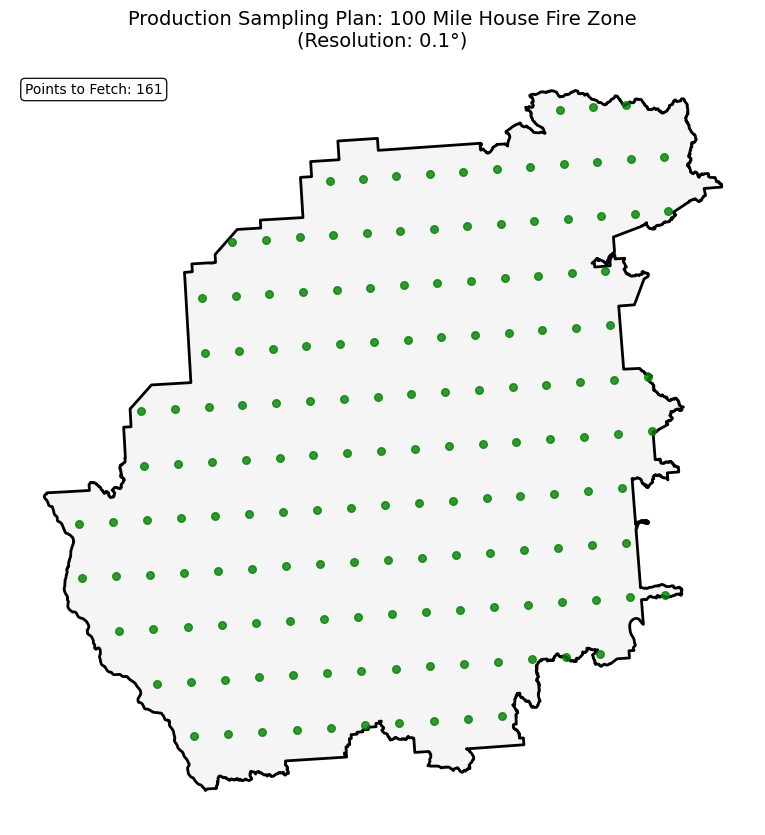

Visualizing: Chilcotin Fire Zone...
   > Grid Generation: Created 651 candidates -> Kept 375 valid points inside zone.


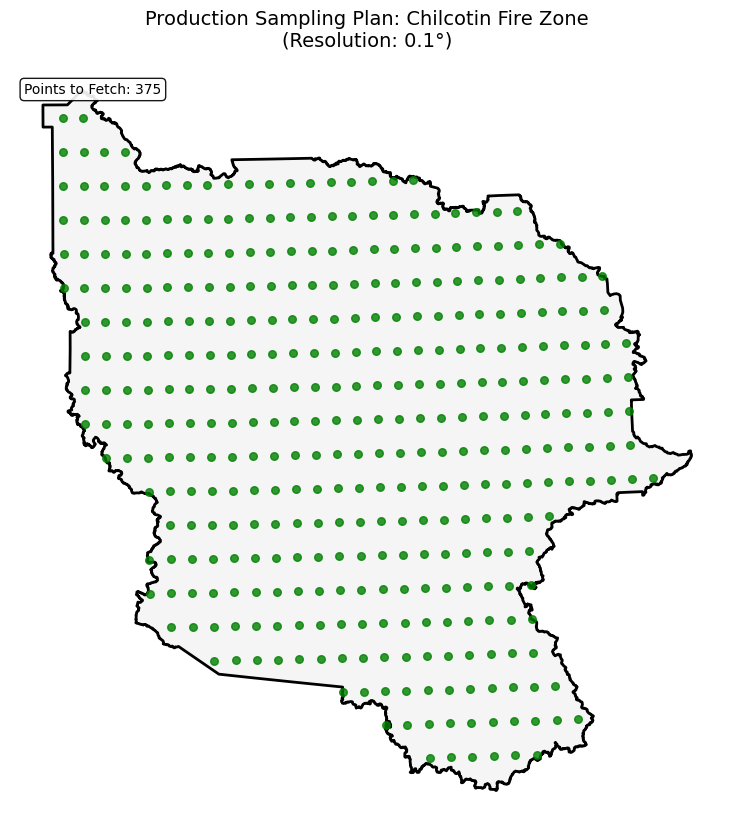

Visualizing: Quesnel Fire Zone...
   > Grid Generation: Created 612 candidates -> Kept 280 valid points inside zone.


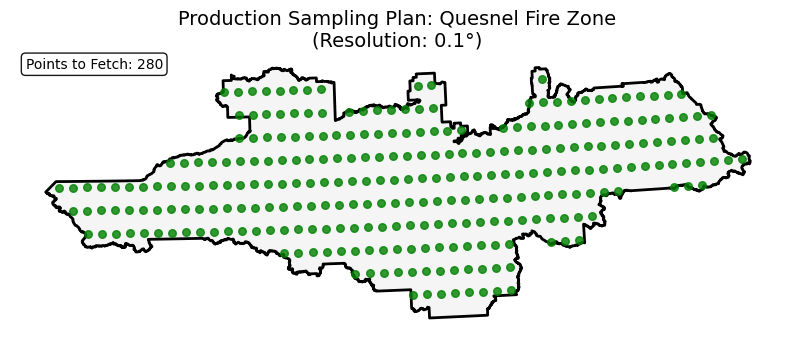

Visualizing: Central Cariboo Fire Zone...
   > Grid Generation: Created 700 candidates -> Kept 273 valid points inside zone.


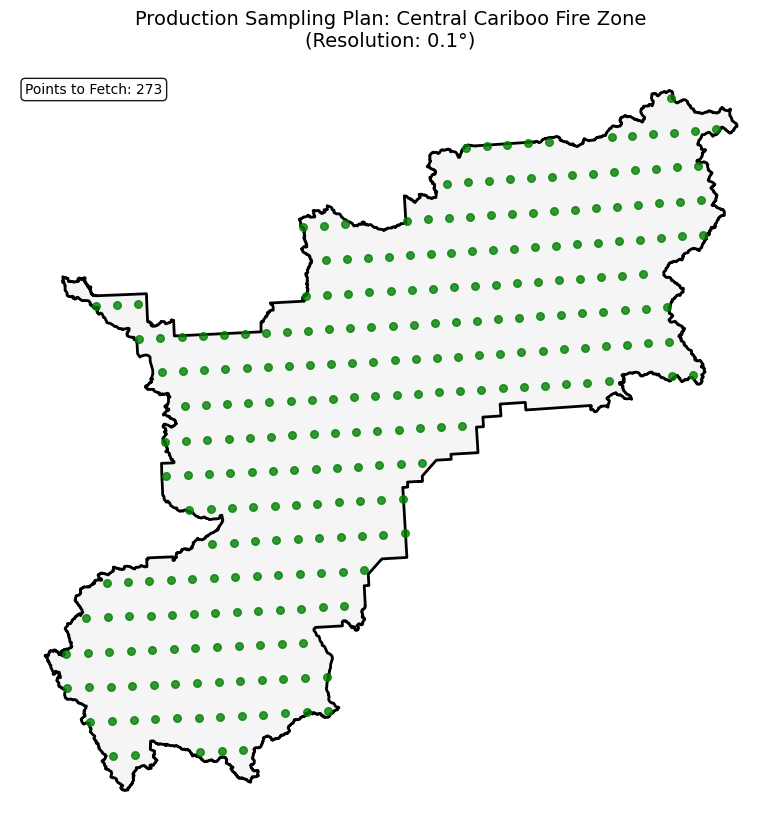

In [15]:

unique_zones = official_gdf['MOF_FIRE_ZONE_NAME'].unique()
print(f"Found {len(unique_zones)} zones to visualize.\n")

for zone_name in unique_zones:
    print(f"Visualizing: {zone_name}...")
  
    target_row = official_gdf[official_gdf['MOF_FIRE_ZONE_NAME'] == zone_name]
    polygon = target_row.geometry.iloc[0]
    
   
    valid_coords = fetcher._generate_valid_grid_points(polygon, resolution=0.1)
    
    if not valid_coords:
        print(f"   ! WARNING: No points generated for {zone_name}")
        continue

   
    points_geom = [Point(lon, lat) for lat, lon in valid_coords]
    points_gdf = gpd.GeoDataFrame(geometry=points_geom, crs="EPSG:4326")
    
    # Project points to match the map (BC Albers)
    points_gdf = points_gdf.to_crs(official_gdf.crs)
    target_poly_gdf = gpd.GeoDataFrame(geometry=[polygon], crs=official_gdf.crs)

    # D. PLOT
    fig, ax = plt.subplots(figsize=(10, 10))
    
    # 1. Draw the Zone Boundary
    target_poly_gdf.plot(ax=ax, color='whitesmoke', edgecolor='black', linewidth=2, zorder=1)
    
    # 2. Draw the Valid Points (Output from Function)
    points_gdf.plot(ax=ax, color='green', marker='o', markersize=30, alpha=0.8, label='Valid Grid Points', zorder=2)
    
    # Formatting
    plt.title(f"Production Sampling Plan: {zone_name}\n(Resolution: 0.1°)", fontsize=14)
    plt.axis('off')
    
    # Stats Text
    plt.text(0.02, 0.95, f"Points to Fetch: {len(points_gdf)}", transform=ax.transAxes,
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))
    
    # Save
    plt.show()
    safe_name = zone_name.replace(" ", "_").lower()
    plt.close() # Close memory to prevent crash
    
   



In [16]:
# now will run master script to generate data

In [17]:
START_DATE = '2012-01-01'
END_DATE = '2023-12-31'  # 11 Years of data for training
RESOLUTION = 0.1         # ~11km grid (High precision)
OUTPUT_DIR = '../../extracted/weather_processed'

In [18]:
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [19]:
zone_list = official_gdf['MOF_FIRE_ZONE_NAME'].unique()

In [20]:
fetcher = CaribooDataFetcher(official_zones_gdf=official_gdf)
all_zones_data = []

print(f"--- STEP 2: STARTING DATA COLLECTION ({START_DATE} to {END_DATE}) ---")

for zone in zone_list:
    print(f"\nPROCESSING: {zone}")
    print("=" * 40)
    
    # Fetch Data
    df = fetcher.fetch_regional_weather_era5(
        zone_name=zone,
        start_date=START_DATE,
        end_date=END_DATE,
        resolution=RESOLUTION
    )
    
    if df is not None:
        # Add Categorical Column for ML (Critical for distinguishing regions)
        df['Zone_Name'] = zone
        
        # Save Individual File (for backup/inspection)
        safe_name = zone.replace(" ", "_").lower()
        filename = f"{OUTPUT_DIR}/weather_{safe_name}.csv"
        df.to_csv(filename, index=False)
        print(f"   > Saved: {filename}")
        
        # Add to master list
        all_zones_data.append(df)
    else:
        print(f"   ! SKIPPED {zone} due to error.")

# ==========================================
# 3. COMPILE MASTER DATASET FOR ML
# ==========================================
print("\n--- STEP 3: COMPILING MASTER DATASET ---")
if all_zones_data:
    master_df = pd.concat(all_zones_data, ignore_index=True)
    
    # Reorder columns for ML readability
    cols = ['Date', 'Zone_Name'] + [c for c in master_df.columns if c not in ['Date', 'Zone_Name']]
    master_df = master_df[cols]
    
    # Save Master File
    master_path = f"{OUTPUT_DIR}/cariboo_master_weather_2012-2023.csv"
    master_df.to_csv(master_path, index=False)
    
    print(f"✓ MASTER DATASET SAVED: {master_path}")
    print(f"  Total Rows: {len(master_df)}")
    print(f"  Features: {list(master_df.columns)}")
else:
    print("No data collected.")

--- STEP 2: STARTING DATA COLLECTION (2012-01-01 to 2023-12-31) ---

PROCESSING: 100 Mile House Fire Zone

Fetching ERA5 daily statistics for 100 Mile House Fire Zone...
   Date Range: 2012-01-01 to 2023-12-31
   Spatial Area: [50.95°N to 52.19°N, -122.29°W to -120.23°W]
   > Requesting 2012-01... 

2026-01-17 08:09:34,281 INFO Request ID is 6708822c-223d-45ce-ae0c-dca061a8533d
2026-01-17 08:09:34,456 INFO status has been updated to accepted
2026-01-17 08:10:07,619 INFO status has been updated to successful


f1589c944c25db361dd911e51fe808b5.zip:   0%|          | 0.00/159k [00:00<?, ?B/s]

✓
   > Requesting 2012-02... 

2026-01-17 08:10:12,828 INFO Request ID is 910810d0-a8b6-4f0e-a055-86690cee519e
2026-01-17 08:10:12,980 INFO status has been updated to accepted
2026-01-17 08:10:46,478 INFO status has been updated to successful


...

2026-01-17 08:11:55,647 INFO Request ID is 6d79315e-d07c-4252-a68b-6e0810aff83b
2026-01-17 08:11:55,785 INFO status has been updated to accepted
2026-01-17 08:12:28,948 INFO status has been updated to successful


2561d89dc291f3c226818fd5e3c86d5f.zip:   0%|          | 0.00/157k [00:00<?, ?B/s]

✓
   > Requesting 2012-06... 

2026-01-17 08:12:33,272 INFO Request ID is 51a2f53c-a21a-4e62-88ee-d92eb52f87c2
2026-01-17 08:12:33,417 INFO status has been updated to accepted


KeyboardInterrupt: 